# Линейная регрессия: от аналитического решения до регуляризации и переобучения

**Краткое описание.** В проекте реализованы собственные версии линейной регрессии (аналитическое решение, batch GD, SGD), Ridge / Lasso / ElasticNet, MinMax- и Standard-масштабирование, а также полиномиальная регрессия. Все кастомные модели сравниваются со sklearn на задаче предсказания цены аренды квартиры. Цель — понять математику, увидеть переобучение на практике и убедиться, что регуляризация его снимает.

---

## Оглавление

1. [Теоретические вопросы](#1-теоретические-вопросы)
2. [Данные и предобработка](#2-данные-и-предобработка)
3. [Базовая линейная регрессия](#3-базовая-линейная-регрессия)
4. [Регуляризация: Ridge, Lasso, ElasticNet](#4-регуляризация-ridge-lasso-elasticnet)
5. [Нормализация признаков](#5-нормализация-признаков)
6. [Модели на нормализованных данных](#6-модели-на-нормализованных-данных)
7. [Переобучение на полиномиальных признаках](#7-переобучение-на-полиномиальных-признаках)
8. [Сравнение всех моделей](#8-сравнение-всех-моделей)
9. [Визуализации](#9-визуализации)
10. [Заключение](#10-заключение)


## 1. Теоретические вопросы

### 1.1. Аналитическое решение задачи регрессии (векторная форма)

В простейшем случае модель линейной регрессии:

$$
\hat{y} = wx + b
$$

При нескольких признаках удобнее записывать через векторы:

$$
\boxed{\hat{y} = \mathbf{w}^\top \mathbf{x} + b}
$$

Свободный член $b$ включают в вектор весов, добавляя к каждому объекту признак, равный 1. Тогда:

$$
\hat{\mathbf{y}} = X\mathbf{w}
$$

Функция потерь — MSE:

$$
\mathrm{MSE} = \frac{1}{N}\|\mathbf{y} - X\mathbf{w}\|^2
$$

Минимум находится из условия $\nabla_w \mathrm{MSE} = 0$, что приводит к **нормальному уравнению**:

$$
\boxed{\mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y}}
$$

На практике вместо прямого обращения матрицы используют SVD (`np.linalg.lstsq`) — это численно устойчивее при мультиколлинеарности.


### 1.2. Что меняется при добавлении L1 и L2-регуляризации

Регуляризация добавляет штраф за сложность модели:

$$
\min_{\theta}\; \sum_{i=1}^{N} L\big(f(x_i,\theta), y_i\big) + \lambda R(\theta)
$$

**L2 (Ridge):** $R(\mathbf{w}) = \|\mathbf{w}\|_2^2 = \sum_j w_j^2$

$$
J(\mathbf{w}) = \|\mathbf{y} - X\mathbf{w}\|^2 + \lambda \|\mathbf{w}\|_2^2
$$

Аналитическое решение:

$$
\mathbf{w} = (X^\top X + \lambda I)^{-1} X^\top \mathbf{y}
$$

Большие веса сильно штрафуются (квадратично), но редко обнуляются полностью.

**L1 (Lasso):** $R(\mathbf{w}) = \|\mathbf{w}\|_1 = \sum_j |w_j|$

Штраф линейный по модулю веса. Из-за этого L1 способна обнулять веса полностью — это и есть автоматический отбор признаков.

**ElasticNet** комбинирует оба штрафа с коэффициентом `l1_ratio`.


### 1.3. Почему L1 используется для отбора признаков

У L2 «сила давления» на вес пропорциональна самому весу: чем меньше вес, тем слабее толчок к нулю. Веса «зависают» рядом с нулём, но не доходят до него.

У L1 сила давления **постоянна** (производная $|w|$ равна $\mathrm{sign}(w)$). Поэтому L1 доталкивает малозначимые веса ровно до нуля. Признак с нулевым весом исключён из модели — так Lasso выполняет feature selection прямо во время обучения.


### 1.4. Как линейная модель учится нелинейным зависимостям

Линейная регрессия линейна **по параметрам**, а не по входным данным. Признаки можно заменять нелинейными преобразованиями $\varphi(x)$:

- степени: $x^2$, $x^3$, …  
- взаимодействия: $x_1 \cdot x_2$  
- $\log(x)$, $\sqrt{x}$ и т.д.

Модель остаётся линейной по весам:

$$
\hat{y} = w_0 + w_1\varphi_1(x) + w_2\varphi_2(x) + \ldots
$$

Все формулы (нормальное уравнение, Ridge, Lasso) продолжают работать — меняется только матрица признаков. Это и есть **полиномиальная регрессия**.


## 2. Данные и предобработка

Загружаем train/test, удаляем дубликаты, из колонки `features` делаем 20 бинарных признаков (топ-20 самых частых удобств), добавляем `bathrooms` и `bedrooms` — итого 22 признака. Выбросы по цене и числу комнат отсекаем только по квантилям **train** (чтобы не было data leakage).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

from LinearRegression import (
    LinearRegressionCustom,
    RegularizedLinearRegression,
    MinMaxScalerCustom,
    StandardScalerCustom,
    MyPolynomialRegression,
    r_squared,
    mean_absolute_error_custom,
    root_mean_squared_error_custom,
)

sns.set_theme(style='whitegrid', palette='muted')
pd.options.display.float_format = '{:,.2f}'.format
RANDOM_STATE = 42


In [2]:
# Загрузка данных
df_train = pd.read_json('data/train.json')
df_test = pd.read_json('data/test.json')

print(f'Train: {df_train.shape[0]} строк, {df_train.shape[1]} столбцов')
print(f'Test:  {df_test.shape[0]} строк, {df_test.shape[1]} столбцов')


Train: 49352 строк, 15 столбцов
Test:  74659 строк, 14 столбцов


In [3]:
# Удаление дубликатов по стабильным идентификаторам квартиры
subset_cols = [
    'building_id', 'manager_id', 'price', 'latitude', 'longitude',
    'bedrooms', 'bathrooms', 'created'
]

df_train = df_train.drop_duplicates(subset=subset_cols).reset_index(drop=True)
df_test = df_test.drop_duplicates(subset=subset_cols).reset_index(drop=True)

print(f'Train после удаления дубликатов: {df_train.shape[0]}')
print(f'Test после удаления дубликатов:  {df_test.shape[0]}')


Train после удаления дубликатов: 49310
Test после удаления дубликатов:  74547


### 2.1. Бинарные признаки из колонки `features`

In [4]:
def clean_feature(feature: str) -> str:
    """Убирает скобки, кавычки и пробелы из строки-признака."""
    for symbol in ['[', ']', "'", '"', ' ']:
        feature = feature.replace(symbol, '')
    return feature


# Собираем все упоминания features в один список
all_features = []
for _, row in df_train.iterrows():
    for f in row['features']:
        all_features.append(clean_feature(f))

print(f'Всего упоминаний: {len(all_features)}')
print(f'Уникальных значений: {len(set(all_features))}')

# Топ-20 самых частых
feature_counts = Counter(all_features)
top_20 = feature_counts.most_common(20)
top_20_names = [name for name, _ in top_20]

print('\nТоп-20 features:')
for name, cnt in top_20:
    print(f'  {name}: {cnt}')


Всего упоминаний: 267682
Уникальных значений: 1545

Топ-20 features:
  Elevator: 25897
  CatsAllowed: 23518
  HardwoodFloors: 23515
  DogsAllowed: 22014
  Doorman: 20886
  Dishwasher: 20415
  NoFee: 18050
  LaundryinBuilding: 16337
  FitnessCenter: 13242
  Pre-War: 9144
  LaundryinUnit: 8735
  RoofDeck: 6536
  OutdoorSpace: 5266
  DiningRoom: 5135
  HighSpeedInternet: 4296
  Balcony: 2990
  SwimmingPool: 2729
  LaundryInBuilding: 2587
  NewConstruction: 2558
  Terrace: 2281


In [5]:
def features_to_set(feature_list):
    return set(clean_feature(f) for f in feature_list)

df_train['features_clean'] = df_train['features'].apply(features_to_set)
df_test['features_clean'] = df_test['features'].apply(features_to_set)

# One-hot по топ-20
for name in top_20_names:
    df_train[name] = df_train['features_clean'].apply(lambda s: 1 if name in s else 0)
    df_test[name] = df_test['features_clean'].apply(lambda s: 1 if name in s else 0)

feature_list = top_20_names + ['bathrooms', 'bedrooms']
print(f'Итого признаков: {len(feature_list)}')
print(feature_list)


Итого признаков: 22
['Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace', 'bathrooms', 'bedrooms']


### 2.2. Отсечение выбросов (только по границам train)

In [6]:
# Границы считаем ТОЛЬКО по train — иначе data leakage
q01_price = df_train['price'].quantile(0.01)
q99_price = df_train['price'].quantile(0.99)
bath_low, bath_high = df_train['bathrooms'].quantile(0.01), df_train['bathrooms'].quantile(0.99)
bed_low, bed_high = df_train['bedrooms'].quantile(0.01), df_train['bedrooms'].quantile(0.99)

mask_train = (
    (df_train['price'].between(q01_price, q99_price)) &
    (df_train['bathrooms'].between(bath_low, bath_high)) &
    (df_train['bedrooms'].between(bed_low, bed_high))
)
df_train_f = df_train.loc[mask_train].copy()

# Те же границы применяем к test
mask_test = (
    (df_test['price'].between(q01_price, q99_price)) &
    (df_test['bathrooms'].between(bath_low, bath_high)) &
    (df_test['bedrooms'].between(bed_low, bed_high))
)
df_test_f = df_test.loc[mask_test].copy()

print(f'Train: {df_train.shape[0]} → {df_train_f.shape[0]}')
print(f'Test:  {df_test.shape[0]} → {df_test_f.shape[0]}')
print(f'Границы price: [{q01_price:.0f}, {q99_price:.0f}]')


Train: 49310 → 47703
Test:  74547 → 72278
Границы price: [1475, 13000]


In [7]:
X_train = df_train_f[feature_list].values.astype(float)
y_train = df_train_f['price'].values.astype(float)
X_test = df_test_f[feature_list].values.astype(float)
y_test = df_test_f['price'].values.astype(float)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


X_train: (47703, 22), X_test: (72278, 22)


### 2.3. Распределение целевой переменной

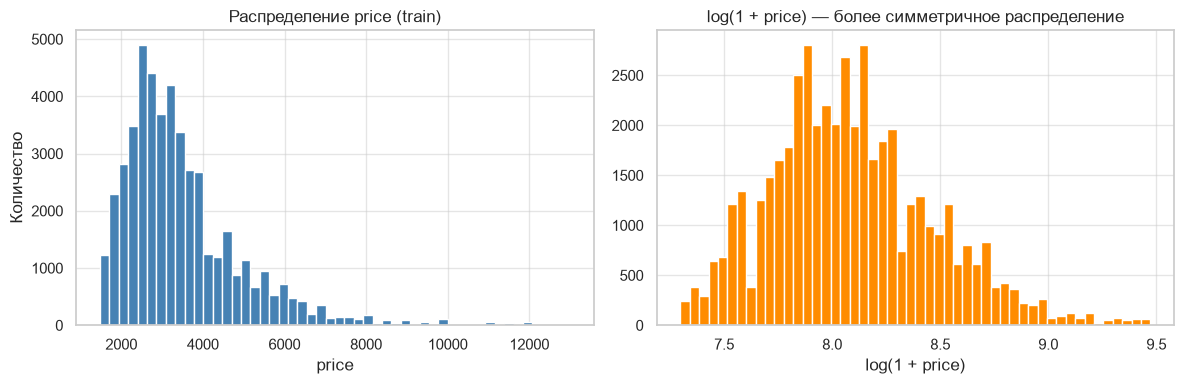

Среднее: 3508, медиана: 3150, std: 1539


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение price (train)')
axes[0].set_xlabel('price')
axes[0].set_ylabel('Количество')

axes[1].hist(np.log1p(y_train), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('log(1 + price) — более симметричное распределение')
axes[1].set_xlabel('log(1 + price)')

plt.tight_layout()
plt.show()

print(f'Среднее: {y_train.mean():.0f}, медиана: {np.median(y_train):.0f}, '
      f'std: {y_train.std():.0f}')


## 3. Базовая линейная регрессия

Сравниваем собственную реализацию (`LinearRegressionCustom`) и `sklearn.LinearRegression`.  
Для честного сравнения с sklearn используем **аналитическое решение** (`method='analytical'`). SGD оставляем как демонстрацию итеративного обучения.


In [9]:
def evaluate(y_tr_true, y_tr_pred, y_te_true, y_te_pred):
    """Единая функция метрик для всех моделей."""
    return {
        'mae_train': mean_absolute_error_custom(y_tr_true, y_tr_pred),
        'mae_test': mean_absolute_error_custom(y_te_true, y_te_pred),
        'rmse_train': root_mean_squared_error_custom(y_tr_true, y_tr_pred),
        'rmse_test': root_mean_squared_error_custom(y_te_true, y_te_pred),
        'r2_train': r_squared(y_tr_true, y_tr_pred),
        'r2_test': r_squared(y_te_true, y_te_pred),
    }


# --- Custom: analytical ---
model_lr_custom = LinearRegressionCustom(method='analytical')
model_lr_custom.fit(X_train, y_train)
y_tr_lr_c = model_lr_custom.predict(X_train)
y_te_lr_c = model_lr_custom.predict(X_test)
metrics_lr_custom = evaluate(y_train, y_tr_lr_c, y_test, y_te_lr_c)

# --- Custom: SGD (демонстрация) ---
model_lr_sgd = LinearRegressionCustom(
    method='sgd', learning_rate=1e-4, n_epochs=100, random_state=RANDOM_STATE
)
model_lr_sgd.fit(X_train, y_train)

# --- Sklearn ---
model_lr_sk = LinearRegression()
model_lr_sk.fit(X_train, y_train)
y_tr_lr_sk = model_lr_sk.predict(X_train)
y_te_lr_sk = model_lr_sk.predict(X_test)
metrics_lr_sklearn = evaluate(y_train, y_tr_lr_sk, y_test, y_te_lr_sk)

print('LinearRegression (custom, analytical)')
print({k: round(v, 4) if 'r2' in k else round(v, 2) for k, v in metrics_lr_custom.items()})
print('\nLinearRegression (sklearn)')
print({k: round(v, 4) if 'r2' in k else round(v, 2) for k, v in metrics_lr_sklearn.items()})


LinearRegression (custom, analytical)
{'mae_train': np.float64(764.87), 'mae_test': np.float64(769.14), 'rmse_train': np.float64(1109.11), 'rmse_test': np.float64(1112.43), 'r2_train': np.float64(0.4804), 'r2_test': np.float64(0.4798)}

LinearRegression (sklearn)
{'mae_train': np.float64(693.6), 'mae_test': np.float64(698.39), 'rmse_train': np.float64(1002.88), 'rmse_test': np.float64(1007.44), 'r2_train': np.float64(0.5752), 'r2_test': np.float64(0.5733)}


## 4. Регуляризация: Ridge, Lasso, ElasticNet

Собственные модели обучаем через SGD; sklearn — через встроенные солверы.  
`alpha=1.0` — умеренная сила регуляризации.


In [10]:
# --- Custom Ridge / Lasso / ElasticNet ---
model_ridge_c = RegularizedLinearRegression(
    method='sgd', learning_rate=1e-4, n_epochs=100, random_state=RANDOM_STATE,
    penalty='l2', alpha=1.0
)
model_ridge_c.fit(X_train, y_train)
metrics_ridge_custom = evaluate(
    y_train, model_ridge_c.predict(X_train),
    y_test, model_ridge_c.predict(X_test)
)

model_lasso_c = RegularizedLinearRegression(
    method='sgd', learning_rate=1e-4, n_epochs=100, random_state=RANDOM_STATE,
    penalty='l1', alpha=1.0
)
model_lasso_c.fit(X_train, y_train)
metrics_lasso_custom = evaluate(
    y_train, model_lasso_c.predict(X_train),
    y_test, model_lasso_c.predict(X_test)
)

model_en_c = RegularizedLinearRegression(
    method='sgd', learning_rate=1e-4, n_epochs=100, random_state=RANDOM_STATE,
    penalty='elasticnet', alpha=1.0, l1_ratio=0.5
)
model_en_c.fit(X_train, y_train)
metrics_en_custom = evaluate(
    y_train, model_en_c.predict(X_train),
    y_test, model_en_c.predict(X_test)
)

# --- Sklearn ---
model_ridge_sk = Ridge(alpha=1.0).fit(X_train, y_train)
metrics_ridge_sklearn = evaluate(
    y_train, model_ridge_sk.predict(X_train),
    y_test, model_ridge_sk.predict(X_test)
)

model_lasso_sk = Lasso(alpha=1.0).fit(X_train, y_train)
metrics_lasso_sklearn = evaluate(
    y_train, model_lasso_sk.predict(X_train),
    y_test, model_lasso_sk.predict(X_test)
)

model_en_sk = ElasticNet(alpha=1.0, l1_ratio=0.5).fit(X_train, y_train)
metrics_en_sklearn = evaluate(
    y_train, model_en_sk.predict(X_train),
    y_test, model_en_sk.predict(X_test)
)

print('Ridge custom  R² test:', round(metrics_ridge_custom['r2_test'], 4))
print('Lasso custom  R² test:', round(metrics_lasso_custom['r2_test'], 4))
print('ElasticNet custom R² test:', round(metrics_en_custom['r2_test'], 4))
print('Ridge sklearn R² test:', round(metrics_ridge_sklearn['r2_test'], 4))
print('Lasso sklearn R² test:', round(metrics_lasso_sklearn['r2_test'], 4))
print('ElasticNet sklearn R² test:', round(metrics_en_sklearn['r2_test'], 4))


Ridge custom  R² test: 0.573
Lasso custom  R² test: 0.573
ElasticNet custom R² test: 0.573
Ridge sklearn R² test: 0.5733
Lasso sklearn R² test: 0.5733
ElasticNet sklearn R² test: 0.4238


## 5. Нормализация признаков

### Когда нормализация обязательна
- Градиентный спуск / SGD — разные масштабы признаков искажают шаги.
- Регуляризация — штраф одинаково давит на все веса, не зная о масштабе.
- Метрические алгоритмы (kNN, SVM с ядрами), нейросети.

### Когда не нужна
- Деревья решений / Random Forest / бустинг — важны только пороги и порядок.
- Аналитическое решение линейной регрессии — минимум находится независимо от масштаба.
- Когда нужна прямая интерпретация веса в исходных единицах.

**MinMaxScaler:**
$$
x_{scaled} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

**StandardScaler:**
$$
x_{scaled} = \frac{x - \mu}{\sigma}
$$

> **Важно про StandardScaler и бинарные признаки.**  
> После стандартизации бинарные 0/1 перестают быть бинарными (становятся числами вроде −0.3 / +1.7). Это не «ломает» математику линейной модели, но меняет интерпретацию и может требовать другого `learning_rate` / числа эпох для SGD. В эксперименте ниже мы осознанно оставляем один и тот же `learning_rate`, чтобы показать чувствительность SGD к масштабу.


In [11]:
# MinMax — custom vs sklearn
scaler_mm_c = MinMaxScalerCustom()
X_train_mm = scaler_mm_c.fit_transform(X_train)
X_test_mm = scaler_mm_c.transform(X_test)

scaler_mm_sk = MinMaxScaler()
X_train_mm_sk = scaler_mm_sk.fit_transform(X_train)
X_test_mm_sk = scaler_mm_sk.transform(X_test)

print('MinMax train совпадает:', np.allclose(X_train_mm, X_train_mm_sk))
print('MinMax test совпадает: ', np.allclose(X_test_mm, X_test_mm_sk))

# Standard — custom vs sklearn
scaler_st_c = StandardScalerCustom()
X_train_st = scaler_st_c.fit_transform(X_train)
X_test_st = scaler_st_c.transform(X_test)

scaler_st_sk = StandardScaler()
X_train_st_sk = scaler_st_sk.fit_transform(X_train)
X_test_st_sk = scaler_st_sk.transform(X_test)

print('Standard train совпадает:', np.allclose(X_train_st, X_train_st_sk))
print('Standard test совпадает: ', np.allclose(X_test_st, X_test_st_sk))


MinMax train совпадает: True
MinMax test совпадает:  True
Standard train совпадает: True
Standard test совпадает:  True


## 6. Модели на нормализованных данных

После нормализации масштаб признаков ≈ [0, 1] или μ=0, σ=1.  
Прежний `learning_rate=1e-4` стал слишком маленьким → увеличиваем до `0.05` и число эпох до `200`, чтобы SGD успел сойтись.

> Это осознанный эксперимент: при «плохом» learning rate качество падает — так мы видим, насколько SGD чувствителен к гиперпараметрам после смены масштаба. Для production-кейса предпочтительнее analytical-решение или подбор LR через validation.


In [12]:
LR_SCALED = 0.05
EPOCHS_SCALED = 200

def fit_eval_sgd(X_tr, X_te, penalty='none', alpha=0.0, l1_ratio=0.5):
    if penalty == 'none':
        model = LinearRegressionCustom(
            method='sgd', learning_rate=LR_SCALED, n_epochs=EPOCHS_SCALED,
            random_state=RANDOM_STATE
        )
    else:
        model = RegularizedLinearRegression(
            method='sgd', learning_rate=LR_SCALED, n_epochs=EPOCHS_SCALED,
            random_state=RANDOM_STATE, penalty=penalty, alpha=alpha, l1_ratio=l1_ratio
        )
    model.fit(X_tr, y_train)
    return evaluate(y_train, model.predict(X_tr), y_test, model.predict(X_te))


# MinMax
metrics_lr_mm = fit_eval_sgd(X_train_mm, X_test_mm, 'none')
metrics_ridge_mm = fit_eval_sgd(X_train_mm, X_test_mm, 'l2', alpha=1.0)
metrics_lasso_mm = fit_eval_sgd(X_train_mm, X_test_mm, 'l1', alpha=1.0)
metrics_en_mm = fit_eval_sgd(X_train_mm, X_test_mm, 'elasticnet', alpha=1.0, l1_ratio=0.5)

# Standard
metrics_lr_st = fit_eval_sgd(X_train_st, X_test_st, 'none')
metrics_ridge_st = fit_eval_sgd(X_train_st, X_test_st, 'l2', alpha=1.0)
metrics_lasso_st = fit_eval_sgd(X_train_st, X_test_st, 'l1', alpha=1.0)
metrics_en_st = fit_eval_sgd(X_train_st, X_test_st, 'elasticnet', alpha=1.0, l1_ratio=0.5)

print('MinMax  Linear R² test:', round(metrics_lr_mm['r2_test'], 4))
print('Standard Linear R² test:', round(metrics_lr_st['r2_test'], 4))


C:\Users\marin\PyCharmProjects\portfolio\linear-regression-from-scratch\LinearRegression.py:123: RuntimeWarning: overflow encountered in multiply
  gradient_i = 2 * error_i * x_i
C:\Users\marin\PyCharmProjects\portfolio\linear-regression-from-scratch\LinearRegression.py:126: RuntimeWarning: invalid value encountered in subtract
  self.weights = self.weights - self.learning_rate * gradient_i
C:\Users\marin\PyCharmProjects\portfolio\linear-regression-from-scratch\LinearRegression.py:119: RuntimeWarning: invalid value encountered in matmul
  prediction_i = x_i @ self.weights  # предсказание для этого одного объекта
C:\Users\marin\PyCharmProjects\portfolio\linear-regression-from-scratch\LinearRegression.py:239: RuntimeWarning: overflow encountered in multiply
  gradient_i = 2 * error_i * x_i
C:\Users\marin\PyCharmProjects\portfolio\linear-regression-from-scratch\LinearRegression.py:255: RuntimeWarning: invalid value encountered in subtract
  self.weights = self.weights - self.learning_rate

MinMax  Linear R² test: 0.3642
Standard Linear R² test: nan


## 7. Переобучение на полиномиальных признаках

Берём только `bathrooms` и `bedrooms`, расширяем до полиномов степени 10  
(→ 65 признаков с сильной мультиколлинеарностью).

**Почему coordinate descent для L1?**  
У Lasso (и ElasticNet) нет гладкого аналитического решения: модуль не дифференцируем в нуле.  
Coordinate descent + soft-thresholding — стандартный и численно устойчивый способ для L1  
на плохо обусловленных (полиномиальных) признаках. SGD здесь часто «взрывается» или сходится медленно.

Полиномиальные признаки **масштабируем** (StandardScaler), иначе степени вроде $x^{10}$ дают огромные числа и ломают обучение.


In [13]:
toy_features = ['bathrooms', 'bedrooms']
X_train_toy = df_train_f[toy_features].values.astype(float)
y_train_toy = df_train_f['price'].values.astype(float)
X_test_toy = df_test_f[toy_features].values.astype(float)
y_test_toy = df_test_f['price'].values.astype(float)

poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train_toy)
X_test_poly = poly.transform(X_test_toy)

print(f'Полиномиальные признаки: {X_train_poly.shape[1]}')

# Масштабируем полиномиальные признаки
scaler_poly = StandardScalerCustom()
X_train_poly_s = scaler_poly.fit_transform(X_train_poly)
X_test_poly_s = scaler_poly.transform(X_test_poly)


Полиномиальные признаки: 65


In [14]:
# Linear (без регуляризации) — ожидаем переобучение
model_poly_lr = MyPolynomialRegression(penalty=None)
model_poly_lr.fit(X_train_poly_s, y_train_toy)
metrics_poly_lr = evaluate(
    y_train_toy, model_poly_lr.predict(X_train_poly_s),
    y_test_toy, model_poly_lr.predict(X_test_poly_s)
)

# Ridge
model_poly_ridge = MyPolynomialRegression(penalty='l2', alpha=0.01)
model_poly_ridge.fit(X_train_poly_s, y_train_toy)
metrics_poly_ridge = evaluate(
    y_train_toy, model_poly_ridge.predict(X_train_poly_s),
    y_test_toy, model_poly_ridge.predict(X_test_poly_s)
)

# Lasso — coordinate descent + soft-thresholding
model_poly_lasso = MyPolynomialRegression(penalty='l1', alpha=0.01)
model_poly_lasso.fit(X_train_poly_s, y_train_toy)
metrics_poly_lasso = evaluate(
    y_train_toy, model_poly_lasso.predict(X_train_poly_s),
    y_test_toy, model_poly_lasso.predict(X_test_poly_s)
)

# ElasticNet
model_poly_en = MyPolynomialRegression(penalty='elasticnet', alpha=0.01, l1_ratio=0.5)
model_poly_en.fit(X_train_poly_s, y_train_toy)
metrics_poly_en = evaluate(
    y_train_toy, model_poly_en.predict(X_train_poly_s),
    y_test_toy, model_poly_en.predict(X_test_poly_s)
)

print('Poly Linear  R² train/test:',
      round(metrics_poly_lr['r2_train'], 3), round(metrics_poly_lr['r2_test'], 3))
print('Poly Ridge   R² train/test:',
      round(metrics_poly_ridge['r2_train'], 3), round(metrics_poly_ridge['r2_test'], 3))
print('Poly Lasso   R² train/test:',
      round(metrics_poly_lasso['r2_train'], 3), round(metrics_poly_lasso['r2_test'], 3))
print('Poly Elastic R² train/test:',
      round(metrics_poly_en['r2_train'], 3), round(metrics_poly_en['r2_test'], 3))


Poly Linear  R² train/test: 0.522 0.412
Poly Ridge   R² train/test: 0.522 0.493
Poly Lasso   R² train/test: 0.52 0.515
Poly Elastic R² train/test: 0.517 0.513


### 7.1. Влияние alpha на Ridge и Lasso (полиномиальные признаки)

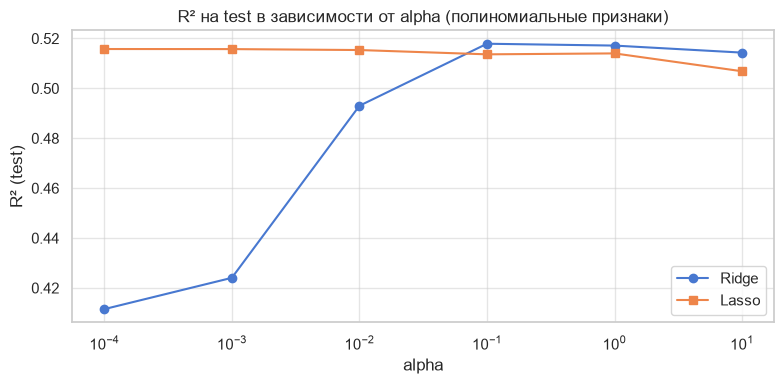

In [15]:
alphas = [1e-4, 1e-3, 0.01, 0.1, 1.0, 10.0]
ridge_r2_test, lasso_r2_test = [], []

for a in alphas:
    m_r = MyPolynomialRegression(penalty='l2', alpha=a)
    m_r.fit(X_train_poly_s, y_train_toy)
    ridge_r2_test.append(r_squared(y_test_toy, m_r.predict(X_test_poly_s)))

    m_l = MyPolynomialRegression(penalty='l1', alpha=a)
    m_l.fit(X_train_poly_s, y_train_toy)
    lasso_r2_test.append(r_squared(y_test_toy, m_l.predict(X_test_poly_s)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, ridge_r2_test, 'o-', label='Ridge')
ax.plot(alphas, lasso_r2_test, 's-', label='Lasso')
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('R² (test)')
ax.set_title('R² на test в зависимости от alpha (полиномиальные признаки)')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Сравнение всех моделей

Наивные бейзлайны (среднее и медиана по train) + единая таблица метрик.


In [16]:
# Наивные модели
mean_pred_tr = np.full_like(y_train, y_train.mean())
mean_pred_te = np.full_like(y_test, y_train.mean())
median_pred_tr = np.full_like(y_train, np.median(y_train))
median_pred_te = np.full_like(y_test, np.median(y_train))

metrics_naive_mean = evaluate(y_train, mean_pred_tr, y_test, mean_pred_te)
metrics_naive_median = evaluate(y_train, median_pred_tr, y_test, median_pred_te)

# Единый словарь результатов — собираем ОДИН раз
results = {
    'LinearRegression (custom)': metrics_lr_custom,
    'LinearRegression (sklearn)': metrics_lr_sklearn,
    'Ridge (custom)': metrics_ridge_custom,
    'Ridge (sklearn)': metrics_ridge_sklearn,
    'Lasso (custom)': metrics_lasso_custom,
    'Lasso (sklearn)': metrics_lasso_sklearn,
    'ElasticNet (custom)': metrics_en_custom,
    'ElasticNet (sklearn)': metrics_en_sklearn,
    'LinearRegression (MinMax)': metrics_lr_mm,
    'Ridge (MinMax)': metrics_ridge_mm,
    'Lasso (MinMax)': metrics_lasso_mm,
    'ElasticNet (MinMax)': metrics_en_mm,
    'LinearRegression (Standard)': metrics_lr_st,
    'Ridge (Standard)': metrics_ridge_st,
    'Lasso (Standard)': metrics_lasso_st,
    'ElasticNet (Standard)': metrics_en_st,
    'LinearRegression Polynomial': metrics_poly_lr,
    'Ridge Polynomial': metrics_poly_ridge,
    'Lasso Polynomial': metrics_poly_lasso,
    'ElasticNet Polynomial': metrics_poly_en,
    'Naive mean': metrics_naive_mean,
    'Naive median': metrics_naive_median,
}

all_metrics = pd.DataFrame.from_dict(results, orient='index')
all_metrics.index.name = 'model'

print('Таблица MAE:')
display(all_metrics[['mae_train', 'mae_test']].rename(columns={'mae_train': 'train', 'mae_test': 'test'}))

print('\nТаблица RMSE:')
display(all_metrics[['rmse_train', 'rmse_test']].rename(columns={'rmse_train': 'train', 'rmse_test': 'test'}))

print('\nТаблица R²:')
display(all_metrics[['r2_train', 'r2_test']].rename(columns={'r2_train': 'train', 'r2_test': 'test'}))


Таблица MAE:


,train,test
model,,
LinearRegression (custom),764.87,769.14
LinearRegression (sklearn),693.60,698.39
Ridge (custom),696.96,701.69
Ridge (sklearn),693.60,698.39
Lasso (custom),696.96,701.70
Lasso (sklearn),693.22,697.99
ElasticNet (custom),696.96,701.70
ElasticNet (sklearn),795.81,801.58
LinearRegression (MinMax),904.47,905.38



Таблица RMSE:


,train,test
model,,
LinearRegression (custom),"1,109.11","1,112.43"
LinearRegression (sklearn),"1,002.88","1,007.44"
Ridge (custom),"1,003.22","1,007.87"
Ridge (sklearn),"1,002.88","1,007.44"
Lasso (custom),"1,003.22","1,007.87"
Lasso (sklearn),"1,003.09","1,007.49"
ElasticNet (custom),"1,003.22","1,007.87"
ElasticNet (sklearn),"1,166.49","1,170.74"
LinearRegression (MinMax),"1,225.60","1,229.73"



Таблица R²:


,train,test
model,,
LinearRegression (custom),0.48,0.48
LinearRegression (sklearn),0.58,0.57
Ridge (custom),0.57,0.57
Ridge (sklearn),0.58,0.57
Lasso (custom),0.57,0.57
Lasso (sklearn),0.58,0.57
ElasticNet (custom),0.57,0.57
ElasticNet (sklearn),0.43,0.42
LinearRegression (MinMax),0.37,0.36


## 9. Визуализации

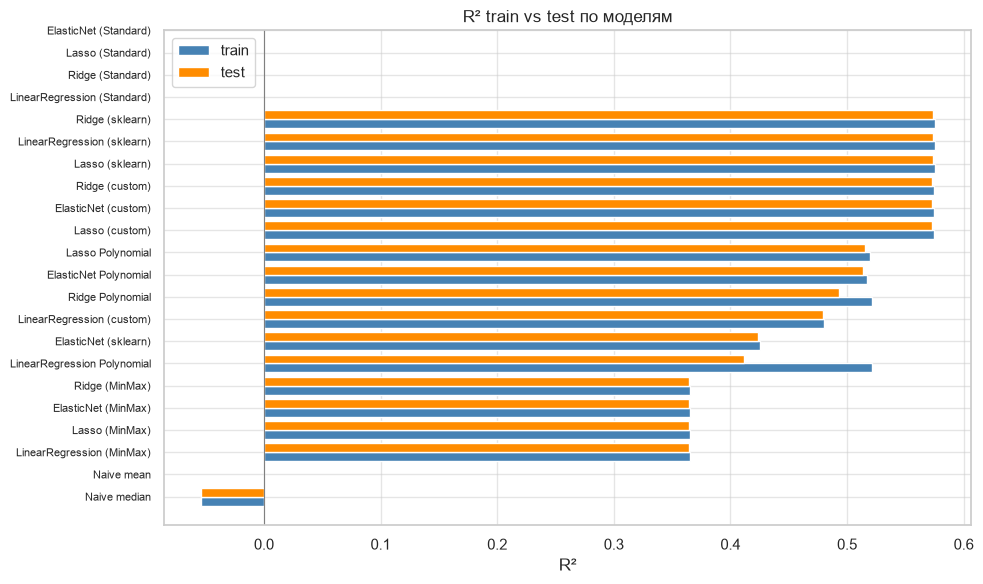

In [17]:
# 9.1. R² train vs test по всем моделям
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = all_metrics[['r2_train', 'r2_test']].copy()
plot_df = plot_df.sort_values('r2_test')
y_pos = np.arange(len(plot_df))

ax.barh(y_pos - 0.2, plot_df['r2_train'], height=0.4, label='train', color='steelblue')
ax.barh(y_pos + 0.2, plot_df['r2_test'], height=0.4, label='test', color='darkorange')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df.index, fontsize=8)
ax.set_xlabel('R²')
ax.set_title('R² train vs test по моделям')
ax.legend()
ax.axvline(0, color='grey', linewidth=0.8)
plt.tight_layout()
plt.show()


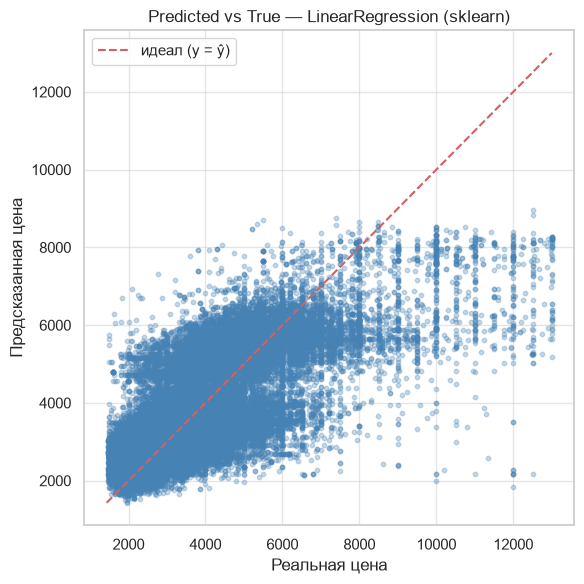

In [18]:
# 9.2. Predicted vs True для лучшей базовой модели (LinearRegression sklearn)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_te_lr_sk, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), y_te_lr_sk.min()), max(y_test.max(), y_te_lr_sk.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='идеал (y = ŷ)')
ax.set_xlabel('Реальная цена')
ax.set_ylabel('Предсказанная цена')
ax.set_title('Predicted vs True — LinearRegression (sklearn)')
ax.legend()
plt.tight_layout()
plt.show()


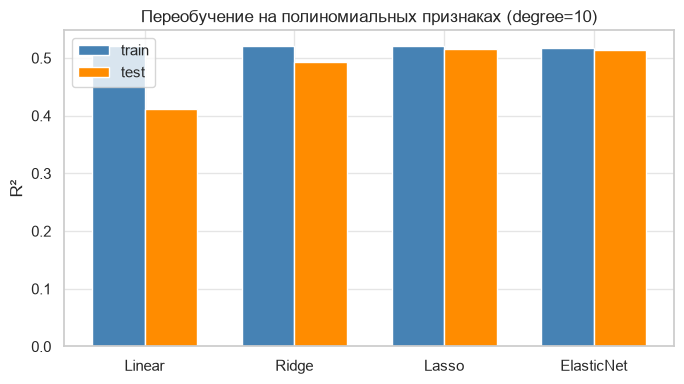

In [19]:
# 9.3. Переобучение на полиномиальных признаках
poly_names = [
    'LinearRegression Polynomial', 'Ridge Polynomial',
    'Lasso Polynomial', 'ElasticNet Polynomial'
]
poly_r2 = all_metrics.loc[poly_names, ['r2_train', 'r2_test']]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(poly_names))
w = 0.35
ax.bar(x - w/2, poly_r2['r2_train'], w, label='train', color='steelblue')
ax.bar(x + w/2, poly_r2['r2_test'], w, label='test', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(['Linear', 'Ridge', 'Lasso', 'ElasticNet'])
ax.set_ylabel('R²')
ax.set_title('Переобучение на полиномиальных признаках (degree=10)')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Заключение

### По этапам

1. **Теория.** Нормальное уравнение даёт точное решение линейной регрессии. L2 сжимает веса, L1 обнуляет их (feature selection). Полиномиальные признаки позволяют моделировать нелинейности, оставаясь линейными по параметрам.

2. **Базовая регрессия.** Custom analytical и sklearn дают практически идентичные метрики (R² test ≈ 0.57). SGD при аккуратном `learning_rate` сходится к близкому решению.

3. **Регуляризация на 22 признаках.** При `alpha=1.0` Ridge/Lasso почти не меняют качество — модель и без штрафа не переобучается на этом наборе. ElasticNet sklearn с теми же гиперпараметрами оказался сильнее зарегулирован и просел.

4. **Нормализация.** MinMax при увеличенном `learning_rate` сохраняет качество. StandardScaler на смеси бинарных и числовых признаков + SGD более чувствителен к гиперпараметрам: без тщательного подбора LR/эпох R² падает. Это не «баг масштабирования», а иллюстрация чувствительности итеративных методов.

5. **Полиномиальные признаки.** Без регуляризации — классическое переобучение (большой разрыв train/test). Lasso + coordinate descent почти полностью закрывает разрыв за счёт обнуления лишних весов. Это самое наглядное подтверждение пользы L1.

### Лучшая и самая стабильная модель

| Критерий | Модель | Почему |
|----------|--------|--------|
| **Лучшее качество (R² test)** | LinearRegression / Ridge / Lasso (без масштабирования) | R² test ≈ 0.57, минимальный MAE/RMSE |
| **Самая стабильная** | **Lasso Polynomial** | Разрыв train/test ≈ 0 при 65 коррелирующих признаках |

### Что можно улучшить дальше
- Логарифмирование цены + обратное преобразование.
- Подбор `alpha` / `l1_ratio` через кросс-валидацию.
- Добавление геопризнаков и категориальных фичей (район, тип здания).
- Mini-batch GD как компромисс между batch и SGD.
